# Droplet Tracking & Counting — Batch Mode

Processes **all videos in a folder** sharing the same calibration and counting line.

**Workflow:**
1. Configure paths and tracking parameters
2. Calibrate once (from a reference video or image)
3. Define the counting line once
4. Process all videos in the input folder automatically
5. Collect results into a single summary DataFrame

## 1. Installation

In [1]:
import sys
!{sys.executable} -m pip install -r requirements.txt --quiet
print("Dependencies installed from requirements.txt")

Dependencies installed from requirements.txt


## 2. Imports

In [2]:
import os
import glob
import pandas as pd
from pathlib import Path

from droplet_tracking.pipeline import (
    TrackingConfig,
    build_droplet_dataframe,
    create_calibration_ui,
    create_line_selector_ui,
    load_model_and_video_info,
    print_tracking_summary,
    process_tracking_video,
    run_batch,
)


## 3. Settings  ← **edit here**

In [ ]:
# --- PATHS -------------------------------------------------------------
MODEL_PATH     = r"runs/droplets_v1/weights/best.pt"
INPUT_FOLDER   = r"/mnt/g/Drop_DL/output/CF"             # folder with videos to process
OUTPUT_FOLDER  = r"/mnt/g/Drop_DL/output/CF/tracked"     # where annotated videos are saved
CAL_VIDEO_PATH = r"calib.mp4"                            # reference video/image for calibration
VIDEO_EXTS     = (".avi", ".mp4", ".mov", ".mkv")        # accepted extensions

# Optional: process only files whose name contains this string.
# Set to "" (empty string) to process ALL videos in the folder.
NAME_FILTER    = ""   # e.g. "FF-I" to match only "FF-I *.avi"

# --- DETECTION ---------------------------------------------------------
CONF        = 0.20    # minimum confidence
IMGSZ       = 640    # inference image size

# --- BYTETRACK ---------------------------------------------------------
TRACK_THRESH = 0.50
TRACK_BUFFER = 30
MATCH_THRESH = 0.75
FRAME_RATE   = 30
MIN_FRAMES   = 1

# --- ANNOTATION STYLE --------------------------------------------------
BOX_THICKNESS       = 20
TRACE_THICKNESS     = 20
LINE_THICKNESS      = 20
LINE_TEXT_THICKNESS = 16
LABEL_TEXT_THICKNESS = 16
LABEL_TEXT_SCALE    = 4.0
LINE_TEXT_SCALE     = 4.8

tracking_config = TrackingConfig(
    conf=CONF,
    imgsz=IMGSZ,
    track_thresh=TRACK_THRESH,
    track_buffer=TRACK_BUFFER,
    match_thresh=MATCH_THRESH,
    frame_rate=FRAME_RATE,
    min_frames=MIN_FRAMES,
    line_margin_px=2.0,
    box_thickness=BOX_THICKNESS,
    trace_thickness=TRACE_THICKNESS,
    line_thickness=LINE_THICKNESS,
    line_text_thickness=LINE_TEXT_THICKNESS,
    label_text_thickness=LABEL_TEXT_THICKNESS,
    label_text_scale=LABEL_TEXT_SCALE,
    line_text_scale=LINE_TEXT_SCALE,
)

# --- COLLECT ALL VIDEO PATHS -------------------------------------------
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

all_videos = sorted([
    p for p in Path(INPUT_FOLDER).iterdir()
    if p.suffix.lower() in VIDEO_EXTS
    and NAME_FILTER.lower() in p.name.lower()
])

print(f"Found {len(all_videos)} video(s) to process:")
for v in all_videos:
    print(f"  {v.name}")

print("\nSettings loaded")
print(tracking_config)

Found 5 video(s) to process:
  5-10.mp4
  5-20.mp4
  5-30.mp4
  5-40.mp4
  5-5.mp4

Settings loaded
TrackingConfig(conf=0.2, imgsz=640, track_thresh=0.5, track_buffer=30, match_thresh=0.75, frame_rate=30, min_frames=1, line_margin_px=2.0, box_thickness=20, trace_thickness=20, line_thickness=20, line_text_thickness=16, label_text_thickness=16, label_text_scale=4.0, line_text_scale=4.8)


## 4. Load model

The model is loaded once and reused for all videos.

In [9]:
# Use the first video just to read video_info here (will reload per-video later).
# The model object is reused across all videos.
model, _ = load_model_and_video_info(MODEL_PATH, str(all_videos[0]))
print("Model loaded.")

Model      : runs/droplets_v1/weights/best.pt
Video      : /mnt/g/Drop_DL/output/CF/5-10.mp4
Resolution : 3840x2160
FPS        : 30
Frames     : 900
Duration   : 30.0s
Model loaded.


## 5. Calibration — run once

Click **two points** over the scale bar and confirm.  
`um_per_px` will be reused for every video.

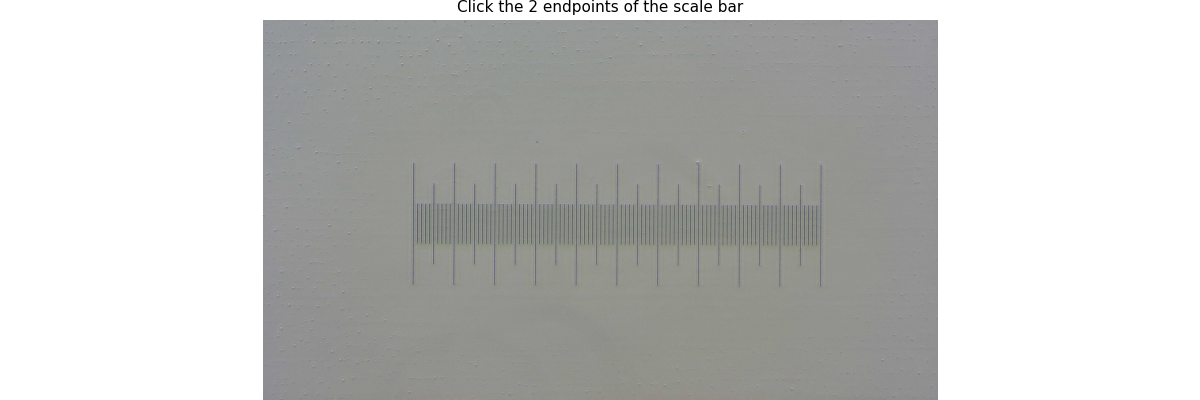

Select 2 points and click Confirm in the widget.


In [ ]:
%matplotlib widget
calibration_state = create_calibration_ui(CAL_VIDEO_PATH, default_reference_um=100.0)
print("Select 2 points and click Confirm in the widget.")

## 6. Define counting line — run once

The line is defined on the **first video** (or any representative frame) and applied to all.

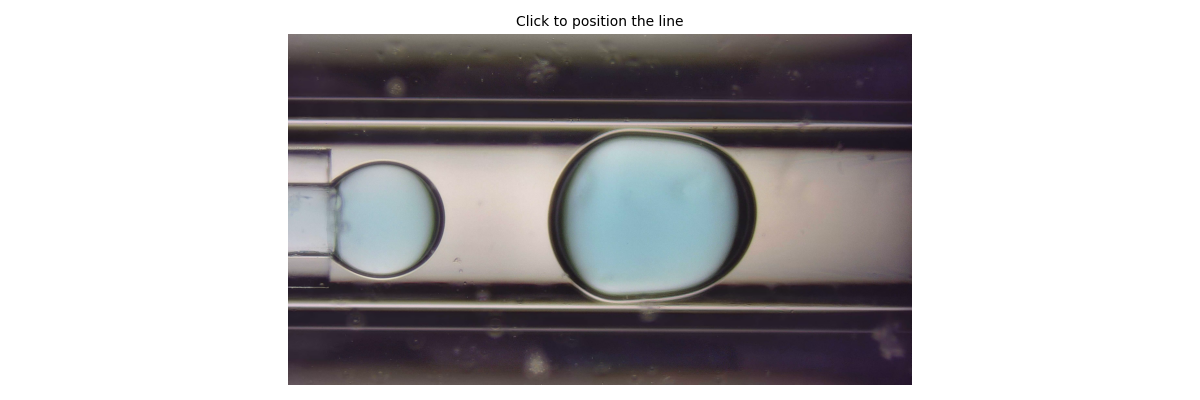

Click on the image, adjust orientation/length, then click Confirm.


In [ ]:
%matplotlib widget
line_state = create_line_selector_ui(str(all_videos[0]))
print("Click on the image, adjust orientation/length, then click Confirm.")

## 7. Batch processing

Runs the full tracking + counting pipeline on every video.  
Progress is printed for each file; errors are caught so the loop continues.

In [19]:
if line_state.get("line_start") is None or line_state.get("line_end") is None:
    raise ValueError("Counting line not confirmed. Run cell 6 and click Confirm.")

batch_results, batch_dfs = run_batch(
    model=model,
    all_videos=all_videos,
    output_folder=OUTPUT_FOLDER,
    model_path=MODEL_PATH,
    line_start=line_state["line_start"],
    line_end=line_state["line_end"],
    config=tracking_config,
    um_per_px=calibration_state.get("um_per_px"),
    window_s=5.0,
)


Starting batch — 5 video(s)

[1/5] 5-10
  Input : /mnt/g/Drop_DL/output/CF/5-10.mp4
  Output: /mnt/g/Drop_DL/output/CF/tracked/5-10_tracked.mp4
Model      : runs/droplets_v1/weights/best.pt
Video      : /mnt/g/Drop_DL/output/CF/5-10.mp4
Resolution : 3840x2160
FPS        : 30
Frames     : 900
Duration   : 30.0s



Video saved to: /mnt/g/Drop_DL/output/CF/tracked/5-10_tracked.mp4
Total droplets : 34
Diameters measured on the line : 34
  EXPERIMENT SUMMARY
  Video          : 5-10.mp4
  Duration       : 30.0 s
  Droplets IN    : 34
  Frequency      : 1.13 droplets/s

  Generation frequency  (Dt = 5 s windows)
    Window   t_start     t_end   count   freq (Hz)  freq (min^-1)
  --------  --------  --------  ------  ----------  ------------
         0        0s        5s       6       1.200         72.00
         1        5s       10s       6       1.200         72.00
         2       10s       15s       5       1.000         60.00
         3       15s       20s       6       1.200         72.00
         4       20s       25s       6       1.200         72.00
         5       25s       30s       5       1.000         60.00

  Freq mean      : 1.133 Hz  (68.00 min^-1)
  Freq SD        : 0.103 Hz
  Freq CV        : 9.1 %

  Diameters & aspect ratio at line crossing  [um]
    frame     id        dx     


Video saved to: /mnt/g/Drop_DL/output/CF/tracked/5-20_tracked.mp4
Total droplets : 46
Diameters measured on the line : 47
  EXPERIMENT SUMMARY
  Video          : 5-20.mp4
  Duration       : 30.3 s
  Droplets IN    : 46
  Frequency      : 1.52 droplets/s

  Generation frequency  (Dt = 5 s windows)
    Window   t_start     t_end   count   freq (Hz)  freq (min^-1)
  --------  --------  --------  ------  ----------  ------------
         0        0s        5s       8       1.600         96.00
         1        5s       10s       8       1.600         96.00
         2       10s       15s       7       1.400         84.00
         3       15s       20s       8       1.600         96.00
         4       20s       25s       8       1.600         96.00
         5       25s       30s       8       1.600         96.00

  Freq mean      : 1.567 Hz  (94.00 min^-1)
  Freq SD        : 0.082 Hz
  Freq CV        : 5.2 %

  Diameters & aspect ratio at line crossing  [um]
    frame     id        dx     


Video saved to: /mnt/g/Drop_DL/output/CF/tracked/5-30_tracked.mp4
Total droplets : 52
Diameters measured on the line : 52
  EXPERIMENT SUMMARY
  Video          : 5-30.mp4
  Duration       : 30.5 s
  Droplets IN    : 52
  Frequency      : 1.70 droplets/s

  Generation frequency  (Dt = 5 s windows)
    Window   t_start     t_end   count   freq (Hz)  freq (min^-1)
  --------  --------  --------  ------  ----------  ------------
         0        0s        5s       8       1.600         96.00
         1        5s       10s       8       1.600         96.00
         2       10s       15s       9       1.800        108.00
         3       15s       20s       9       1.800        108.00
         4       20s       25s       9       1.800        108.00
         5       25s       30s       9       1.800        108.00

  Freq mean      : 1.733 Hz  (104.00 min^-1)
  Freq SD        : 0.103 Hz
  Freq CV        : 6.0 %

  Diameters & aspect ratio at line crossing  [um]
    frame     id        dx    


Video saved to: /mnt/g/Drop_DL/output/CF/tracked/5-40_tracked.mp4
Total droplets : 60
Diameters measured on the line : 60
  EXPERIMENT SUMMARY
  Video          : 5-40.mp4
  Duration       : 30.1 s
  Droplets IN    : 60
  Frequency      : 1.99 droplets/s

  Generation frequency  (Dt = 5 s windows)
    Window   t_start     t_end   count   freq (Hz)  freq (min^-1)
  --------  --------  --------  ------  ----------  ------------
         0        0s        5s      10       2.000        120.00
         1        5s       10s      10       2.000        120.00
         2       10s       15s      10       2.000        120.00
         3       15s       20s      10       2.000        120.00
         4       20s       25s      10       2.000        120.00
         5       25s       30s      10       2.000        120.00

  Freq mean      : 2.000 Hz  (120.00 min^-1)
  Freq SD        : 0.000 Hz
  Freq CV        : 0.0 %

  Diameters & aspect ratio at line crossing  [um]
    frame     id        dx    


Video saved to: /mnt/g/Drop_DL/output/CF/tracked/5-5_tracked.mp4
Total droplets : 26
Diameters measured on the line : 28
  EXPERIMENT SUMMARY
  Video          : 5-5.mp4
  Duration       : 30.5 s
  Droplets IN    : 26
  Frequency      : 0.85 droplets/s

  Generation frequency  (Dt = 5 s windows)
    Window   t_start     t_end   count   freq (Hz)  freq (min^-1)
  --------  --------  --------  ------  ----------  ------------
         0        0s        5s       5       1.000         60.00
         1        5s       10s       4       0.800         48.00
         2       10s       15s       5       1.000         60.00
         3       15s       20s       5       1.000         60.00
         4       20s       25s       4       0.800         48.00
         5       25s       30s       5       1.000         60.00

  Freq mean      : 0.933 Hz  (56.00 min^-1)
  Freq SD        : 0.103 Hz
  Freq CV        : 11.1 %

  Diameters & aspect ratio at line crossing  [um]
    frame     id        dx      

## 8. Batch summary

In [21]:
df_batch = pd.DataFrame(batch_results)
print(df_batch.to_string(index=False))

video  total_count status
 5-10           34     OK
 5-20           46     OK
 5-30           52     OK
 5-40           60     OK
  5-5           26     OK


## 9. Combined droplet DataFrame

All droplets from every video, with a `video` column for identification.

In [22]:
if batch_dfs:
    df_all_drops = pd.concat(batch_dfs, ignore_index=True)
    print(f"Total droplets across all videos: {len(df_all_drops)}")
    df_all_drops
else:
    print("No droplet data collected (all videos may have failed).")

Total droplets across all videos: 221


In [23]:
df_all_drops.head()

,frame,track_id,dx_px,dy_px,d_px,aspect_ratio,dx_um,dy_um,d_um,video
0,7,1,1290.43,1102.75,1196.59,0.8546,549.12,469.26,509.19,5-10
1,33,2,1270.34,1102.78,1186.56,0.8681,540.57,469.27,504.92,5-10
2,59,4,1267.05,1100.60,1183.83,0.8686,539.17,468.34,503.76,5-10
3,86,5,1304.72,1105.72,1205.22,0.8475,555.20,470.52,512.86,5-10
4,112,7,1316.15,1103.46,1209.80,0.8384,560.06,469.56,514.81,5-10


## 10. Export results to CSV

In [24]:
csv_summary = Path(OUTPUT_FOLDER) / "batch_summary.csv"
csv_drops   = Path(OUTPUT_FOLDER) / "all_droplets.csv"

df_batch.to_csv(csv_summary, index=False)
print(f"Batch summary saved → {csv_summary}")

if batch_dfs:
    df_all_drops.to_csv(csv_drops, index=False)
    print(f"All droplets saved  → {csv_drops}")

Batch summary saved → /mnt/g/Drop_DL/output/CF/tracked/batch_summary.csv
All droplets saved  → /mnt/g/Drop_DL/output/CF/tracked/all_droplets.csv
